# Multi-Modal Enhancement — Email & HTTP Integration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import re
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from scipy.stats import ttest_ind

In [5]:
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts')
ART_DIR = Path('/content/drive/MyDrive/artifacts')
# RAW_DIR = Path('../r4.1')
RAW_DIR = Path('/content/drive/MyDrive/r4.1')
keras.utils.set_random_seed(42)

## Load the engineered features
Starting from the labelled, engineered matrix and keep the user key so the new modalities can be joined per user.

In [6]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet')
y = fe['consensus_loose'].astype(int)
fe.shape, int(y.sum())

((1000, 35), 90)

## Email feature engineering
The email log is too large to hold comfortably in memory alongside the model, so streaming it in chunks and accumulate per-user aggregates as we go, never materialising the full table. For each user we track volume, message size (via running sum and sum-of-squares so the standard deviation can be recovered), attachment load, CC/BCC usage, and off-hours / weekend timing.

In [7]:
EMAIL_COLS = ['date', 'user', 'size', 'attachments', 'cc', 'bcc']

def email_chunk_aggregate(path, chunksize=200_000):
    parts = []
    for chunk in pd.read_csv(path, usecols=EMAIL_COLS, parse_dates=['date'],
                             chunksize=chunksize, low_memory=False):
        hour = chunk['date'].dt.hour
        dow = chunk['date'].dt.dayofweek
        chunk = chunk.assign(
            hour=hour,
            after=((hour < 8) | (hour > 18)).astype(int),
            weekend=dow.isin([5, 6]).astype(int),
            size_sq=chunk['size'].astype('float64') ** 2,
            has_cc=chunk['cc'].notna().astype(int),
            has_bcc=chunk['bcc'].notna().astype(int),
        )
        g = chunk.groupby('user')
        parts.append(pd.DataFrame({
            'n_email': g.size(),
            'size_sum': g['size'].sum(),
            'size_sq': g['size_sq'].sum(),
            'attach_sum': g['attachments'].sum(),
            'after_email': g['after'].sum(),
            'weekend_email': g['weekend'].sum(),
            'hour_sum': g['hour'].sum(),
            'cc_sum': g['has_cc'].sum(),
            'bcc_sum': g['has_bcc'].sum(),
        }))
    return pd.concat(parts).groupby(level=0).sum()

In [8]:
email_agg = email_chunk_aggregate(RAW_DIR / 'email.csv')
gc.collect()
email_agg.shape

(1000, 9)

From the running sums we derive interpretable per-user features. Ratios use the standard x / (total + 1) smoothing so users with few emails are not pushed to extreme values.

In [9]:
n = email_agg['n_email']
email_features = pd.DataFrame({
    'user': email_agg.index,
    'total_emails': n.values,
    'avg_email_size': (email_agg['size_sum'] / n).values,
    'std_email_size': np.sqrt(np.maximum(
        email_agg['size_sq'] / n - (email_agg['size_sum'] / n) ** 2, 0)).values,
    'total_attachments': email_agg['attach_sum'].values,
    'after_hours_emails': email_agg['after_email'].values,
    'weekend_emails': email_agg['weekend_email'].values,
    'avg_email_hour': (email_agg['hour_sum'] / n).values,
    'after_hours_email_ratio': (email_agg['after_email'] / (n + 1)).values,
    'weekend_email_ratio': (email_agg['weekend_email'] / (n + 1)).values,
    'cc_usage_ratio': (email_agg['cc_sum'] / (n + 1)).values,
    'bcc_usage_ratio': (email_agg['bcc_sum'] / (n + 1)).values,
}).reset_index(drop=True)
email_features.head()

,user,total_emails,avg_email_size,std_email_size,total_attachments,after_hours_emails,weekend_emails,avg_email_hour,after_hours_email_ratio,weekend_email_ratio,cc_usage_ratio,bcc_usage_ratio
0,AAB0224,3683,29967.796362,9893.083364,0,0,0,11.849308,0.000000,0.0,0.270630,0.0
1,AAD0986,2995,29843.042404,10035.197337,0,0,0,11.831720,0.000000,0.0,0.264352,0.0
2,AAH0706,339,30305.690265,9792.069400,166,20,0,11.923304,0.058824,0.0,0.297059,0.0
3,AAR0566,3043,30150.097930,10143.459309,623,349,0,11.578705,0.114652,0.0,0.269382,0.0
4,AAT0419,3018,29847.425116,10160.561180,1120,22,0,12.162359,0.007287,0.0,0.271613,0.0


Email behaviour is now summarised per user without ever loading the full log. The temporal ratios (after_hours_email_ratio, weekend_email_ratio) and the BCC usage rate are the features most likely to separate anomalous from normal senders, since covert communication tends to shift outside business hours and lean on blind copies.

## HTTP feature engineering
The HTTP log is ~15 GB. Following the same reasoning as the exploration notebook, we read a sequential sample of the first HTTP_MAX_ROWS records rather than the whole file. This keeps memory and runtime bounded while still covering all 1,000 users.

In [10]:
HTTP_MAX_ROWS = 3_000_000
HTTP_COLS = ['date', 'user', 'url']

def http_sample(path, max_rows, chunksize=200_000):
    parts, seen = [], 0
    for chunk in pd.read_csv(path, usecols=HTTP_COLS, parse_dates=['date'],
                             chunksize=chunksize, low_memory=False):
        parts.append(chunk)
        seen += len(chunk)
        if seen >= max_rows:
            break
    return pd.concat(parts, ignore_index=True)

In [11]:
http = http_sample(RAW_DIR / 'http.csv', HTTP_MAX_ROWS)
http['domain'] = http['url'].astype(str).str.extract(r'https?://([^/]+)', expand=False)
http['hour'] = http['date'].dt.hour
http['dow'] = http['date'].dt.dayofweek
http['after'] = ((http['hour'] < 8) | (http['hour'] > 18)).astype(int)
http['weekend'] = http['dow'].isin([5, 6]).astype(int)
http.shape, http['user'].nunique()

((3000000, 8), 1000)

In [12]:
g = http.groupby('user')
tot = g.size()
http_features = pd.DataFrame({
    'user': tot.index,
    'total_http_requests': tot.values,
    'unique_domains_visited': g['domain'].nunique().values,
    'after_hours_browsing': g['after'].sum().values,
    'weekend_browsing': g['weekend'].sum().values,
    'avg_browsing_hour': g['hour'].mean().values,
    'after_hours_browsing_ratio': (g['after'].sum() / (tot + 1)).values,
    'weekend_browsing_ratio': (g['weekend'].sum() / (tot + 1)).values,
    'domain_diversity_ratio': (g['domain'].nunique() / (tot + 1)).values,
}).reset_index(drop=True)
del http
gc.collect()
http_features.head()

,user,total_http_requests,unique_domains_visited,after_hours_browsing,weekend_browsing,avg_browsing_hour,after_hours_browsing_ratio,weekend_browsing_ratio,domain_diversity_ratio
0,AAB0224,3876,82,0,0,11.798762,0.000000,0.0,0.021150
1,AAD0986,3237,101,0,0,11.788384,0.000000,0.0,0.031192
2,AAH0706,340,81,19,0,11.667647,0.055718,0.0,0.237537
3,AAR0566,3241,143,410,0,11.427337,0.126465,0.0,0.044109
4,AAT0419,3235,74,37,0,11.921793,0.011434,0.0,0.022868


## Merge the modalities
Left-join email and HTTP features onto the engineered matrix. Users absent from a log (e.g. no sampled HTTP rows) get zeros, which is the correct default for count-based features.

In [13]:
enh = (fe
       .merge(email_features, on='user', how='left')
       .merge(http_features, on='user', how='left'))
new_cols = [c for c in enh.columns if c not in fe.columns]
enh[new_cols] = enh[new_cols].fillna(0)
enh.shape, len(new_cols)

((1000, 54), 19)

## Do the new signals track anomalies?
Before modelling, we check whether the communication features carry any anomaly signal at all, by comparing group means and correlating each new feature with the label.

In [14]:
corr = (enh[new_cols].corrwith(y.astype(float))
        .sort_values(key=np.abs, ascending=False))
corr.head(10).round(3)

,0
weekend_email_ratio,0.283
weekend_browsing_ratio,0.278
weekend_browsing,0.243
weekend_emails,0.242
cc_usage_ratio,0.182
bcc_usage_ratio,0.182
total_http_requests,0.059
total_attachments,0.059
total_emails,0.058
avg_email_hour,-0.055


In [15]:
def group_means(col):
    a = enh.loc[y == 1, col]
    nrm = enh.loc[y == 0, col]
    t, p = ttest_ind(a, nrm, equal_var=False)
    return pd.Series({'anomaly_mean': a.mean(), 'normal_mean': nrm.mean(), 'p_value': p})

signal = pd.DataFrame({c: group_means(c) for c in
                       ['weekend_email_ratio', 'weekend_browsing_ratio',
                        'after_hours_email_ratio', 'bcc_usage_ratio',
                        'total_emails', 'total_http_requests']}).T
signal.round(4)

,anomaly_mean,normal_mean,p_value
weekend_email_ratio,0.0671,0.0122,0.0000
weekend_browsing_ratio,0.0671,0.0124,0.0000
after_hours_email_ratio,0.0515,0.0479,0.5674
bcc_usage_ratio,0.2778,0.1290,0.0000
total_emails,3078.9111,2699.1846,0.1605
total_http_requests,3379.2667,2962.4901,0.1441


## Enhanced multi-input branches
We reuse the four-branch grouping from Notebook 06 and extend each branch with the relevant new modality features: volume gains email/HTTP counts, the temporal branch gains the off-hours/weekend communication ratios, and the psychometric branch gains CC/BCC communication-style ratios.

In [16]:
base = json.load(open(ART_DIR / 'dl_branch_manifest.json'))

enh_branches = {
    'volume': base['volume'] + ['total_emails', 'total_attachments',
                                'total_http_requests', 'unique_domains_visited'],
    'temporal': base['temporal'] + ['after_hours_emails', 'weekend_emails',
                                    'after_hours_email_ratio', 'weekend_email_ratio',
                                    'after_hours_browsing', 'weekend_browsing',
                                    'after_hours_browsing_ratio', 'weekend_browsing_ratio'],
    'access': base['access'] + ['domain_diversity_ratio'],
    'psych': base['psych'] + ['cc_usage_ratio', 'bcc_usage_ratio'],
}
{k: len(v) for k, v in enh_branches.items()}

{'volume': 12, 'temporal': 20, 'access': 4, 'psych': 10}

The focal loss and the branch model are identical to Notebook 06. We hold the split fixed (same random_state) so the base and enhanced models are judged on the same users.

In [17]:
def focal_loss(alpha=0.75, gamma=2.0):
    def loss(y_true, y_pred):
        eps = keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        y_true = tf.cast(y_true, y_pred.dtype)
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        a_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return tf.reduce_mean(-a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss

In [18]:
def build_model(branch_dims):
    inputs, encoded = [], []
    for name, d in branch_dims.items():
        inp = layers.Input(shape=(d,), name=f'{name}_in')
        x = layers.Dense(max(16, 2 * d), activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(max(8, d), activation='relu')(x)
        inputs.append(inp); encoded.append(x)
    h = layers.Concatenate()(encoded)
    h = layers.Dense(48, activation='relu')(h)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(24, activation='relu')(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(1, activation='sigmoid', name='anomaly')(h)
    return keras.Model(inputs=inputs, outputs=out)

In [19]:
idx = np.arange(len(enh))
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx, y, test_size=0.4, random_state=42, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
len(idx_train), len(idx_val), len(idx_test)

(600, 200, 200)

A small helper builds the scaled, per-branch input lists for any branch definition, fitting the scalers on the training rows only.

In [20]:
def prepare(branch_def):
    scalers = {}
    def make(row_idx, fit=False):
        out = []
        for name, feats in branch_def.items():
            block = enh.loc[row_idx, feats].fillna(0).values.astype('float32')
            if fit:
                scalers[name] = StandardScaler().fit(block)
            out.append(scalers[name].transform(block).astype('float32'))
        return out
    Xtr = make(idx_train, fit=True)
    Xva = make(idx_val)
    Xte = make(idx_test)
    dims = {k: len(v) for k, v in branch_def.items()}
    return Xtr, Xva, Xte, dims

In [21]:
def train_eval(branch_def, seed=42):
    keras.utils.set_random_seed(seed)
    Xtr, Xva, Xte, dims = prepare(branch_def)
    model = build_model(dims)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=focal_loss(),
                  metrics=[keras.metrics.AUC(name='pr_auc', curve='PR')])
    cb = [keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                                        patience=20, restore_best_weights=True),
          keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=8, min_lr=1e-4)]
    model.fit(Xtr, y_train.values, validation_data=(Xva, y_val.values),
              epochs=150, batch_size=32, callbacks=cb, verbose=0)
    proba = model.predict(Xte, verbose=0).ravel()
    return model, proba

## Train the behavioural-only baseline
First we retrain the Notebook-06 design on the same split.

In [22]:
base_model, base_proba = train_eval(base)
base_roc = roc_auc_score(y_test, base_proba)
base_pr = average_precision_score(y_test, base_proba)
round(base_roc, 3), round(base_pr, 3)

(np.float64(0.901), np.float64(0.546))

## Train the enhanced model
Now the same architecture with email and HTTP features added to each branch.

In [23]:
enh_model, enh_proba = train_eval(enh_branches)
enh_roc = roc_auc_score(y_test, enh_proba)
enh_pr = average_precision_score(y_test, enh_proba)
round(enh_roc, 3), round(enh_pr, 3)

(np.float64(0.892), np.float64(0.563))

## Comparison

In [24]:
compare = pd.DataFrame({
    'roc_auc': [base_roc, enh_roc],
    'pr_auc': [base_pr, enh_pr],
}, index=['Behavioural only', 'With email + HTTP']).round(3)
compare

,roc_auc,pr_auc
Behavioural only,0.901,0.546
With email + HTTP,0.892,0.563


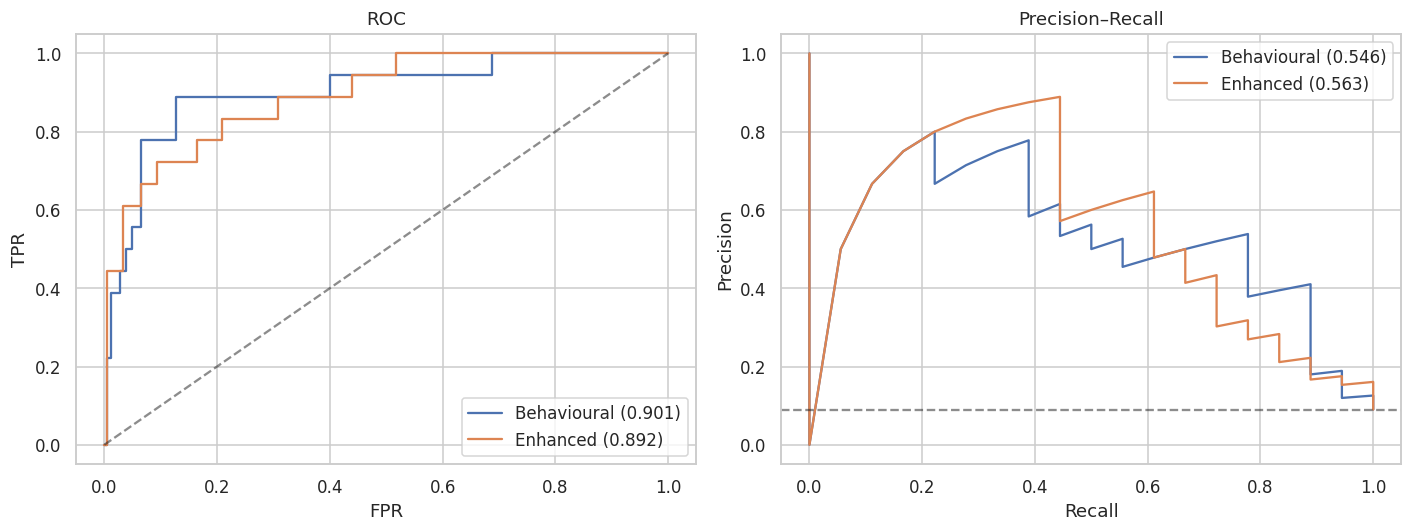

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in [('Behavioural', base_proba), ('Enhanced', enh_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} ({average_precision_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5)
axes[1].set_title('Precision–Recall'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

In [26]:
enh.to_parquet(ART_DIR / 'cert_enhanced_multimodal.parquet', index=False)
json.dump(enh_branches, open(ART_DIR / 'dl_enhanced_branch_manifest.json', 'w'), indent=2)
sorted(p.name for p in ART_DIR.glob('cert_enhanced*')) +     sorted(p.name for p in ART_DIR.glob('dl_enhanced*'))

['cert_enhanced_multimodal.parquet', 'dl_enhanced_branch_manifest.json']